# 02 · DES SN5YR SNe

Four cosmological scenarios over **DES SN5YR** (1820–1829 SNe Ia, distance
modulus already calibrated).

### Key differences vs Pantheon+ (notebook 01)

- **NO Cepheids**: the DES Hubble Diagram already provides calibrated mu (not raw
  m_b). The absolute magnitude offset is marginalized analytically with
  `chi2 - B^2/C + log(C / (2 pi))`.
- **H0 fixed at 70 km/s/Mpc** in all scenarios: without a Cepheid anchor, BAO
  only measures the geometry of the expansion, not H0.
- **DA instead of DL**: chi2 uses `mu = 5 * log10[(1 + zHD) * (1 + zHEL) * DA] + 25`
  via `angular_diameter_distance` (equivalent but faster than DL).
- **2024 vs 2025**: two releases with different covariance formats
  (see `cosmoml/data/des.py`).

Shared pipeline: `train_xgb(log_target=True)` (model caching disabled by default), contours at
`res=100, sigma=2.0, theory_threshold=12`.


## Index

| Sec. | Scenario              | Model        | Dim | Data |
|------|-----------------------|--------------|-----|------|
| [2.1](#2-1) | **wCDM, DES2024**       | FlatwCDM     | 2 (Om, w)       | DES SN5YR 2024 release |
| [2.2](#2-2) | **wCDM, DES2025**       | FlatwCDM     | 2 (Om, w)       | DES SN5YR 2025 release |
| [2.3](#2-3) | **w0waCDM, DES2024**    | Flatw0waCDM  | 3 (Om, w0, wa)  | DES SN5YR 2024 release |
| [2.4](#2-4) | **w0waCDM, DES2025**    | Flatw0waCDM  | 3 (Om, w0, wa)  | DES SN5YR 2025 release |

> **Cepheids**: NOT used in any DES scenario (DES has no external Cepheid
> calibrators, only the homogeneous Hubble Diagram).


## <a id="setup"></a>Setup (run first)


In [87]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_des_2024, load_des_2025
from cosmoml.theory import chi2_sne_des

from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR

use_paper_style()

NB_NAME = "02_SN_DES"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Set to True to retrain models (ignore cache)
FORCE_RETRAIN = False

print(f"Datasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Models:    {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figures:   {FIGURES_DIR}/{{SECTION}}_*.png")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Models:    /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figures:   /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/{SECTION}_*.png


## <a id="2-1"></a>2.1 wCDM with DES2024 — 2D (Om, w)

**Data:** DES-SN5YR release 2024 (1829 SNe).
**Model:** `FlatwCDM` with H0 = 70 fixed.
**Cepheids:** **NO**.

The 2024 `STAT+SYS_2024.txt.gz` matrix is the systematic covariance only — the
loader adds `MUERR_FINAL**2` to the diagonal before inverting.


In [88]:
SECTION = "2_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
H0_FIXED = 70.0

des = load_des_2024()
print(f"DES SN5YR 2024: {len(des)} SNe, z [{des.z.min():.3f}, {des.z.max():.3f}]")

def chi2_fn(Om, w):
    return chi2_sne_des(des, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3, -1.0])))
_m.limits = [(0.05, 0.55), (-1.6, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2024: 1829 SNe, z [0.025, 1.121]
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2669  w=-0.8015
chi2(best-fit) = 1647.67


In [89]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[dict(Om=(max(0.05, REF['Om']-0.20), REF['Om']+0.20),
                     w=(REF['w']-0.50, REF['w']+0.50), _n=8_000)],
        anchor=REF, n_anchor=2000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_1_dataset.csv)
Evaluating chi2 at 8000 points across 11 cores...
     2000/8000 ( 25.0%) | elapsed   75.5s | ETA  226.4s |     26 pts/s
     4000/8000 ( 50.0%) | elapsed  159.1s | ETA  159.1s |     25 pts/s
     6000/8000 ( 75.0%) | elapsed  306.6s | ETA  102.2s |     20 pts/s
     8000/8000 (100.0%) | elapsed  356.0s | ETA    0.0s |     22 pts/s
  done in 356.2s
  anchor {'Om': 0.26685527465872433, 'w': -0.8014552186639804} -> chi2=1647.668 repeated 2000x
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_1_dataset.csv (10000 rows)
min chi2 = 1647.668


In [90]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=False,
)

  target in shifted-log10: range [0.000, 3.097]
  training: 16.39s | R2=0.99889 | best_iter=695/3000  (early stop, ~77% saved)
  model cached: 2_1_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_learning_curve.png


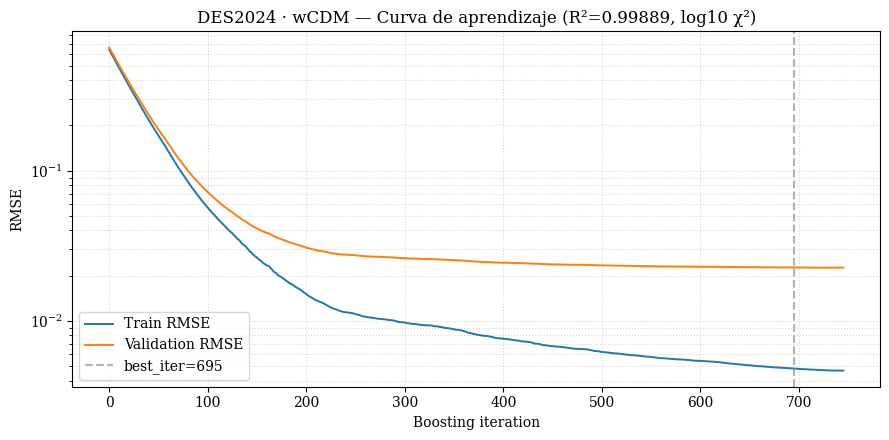

In [91]:
plot_learning_curve(
    info,
    title=f"DES2024 · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_Om_w.png


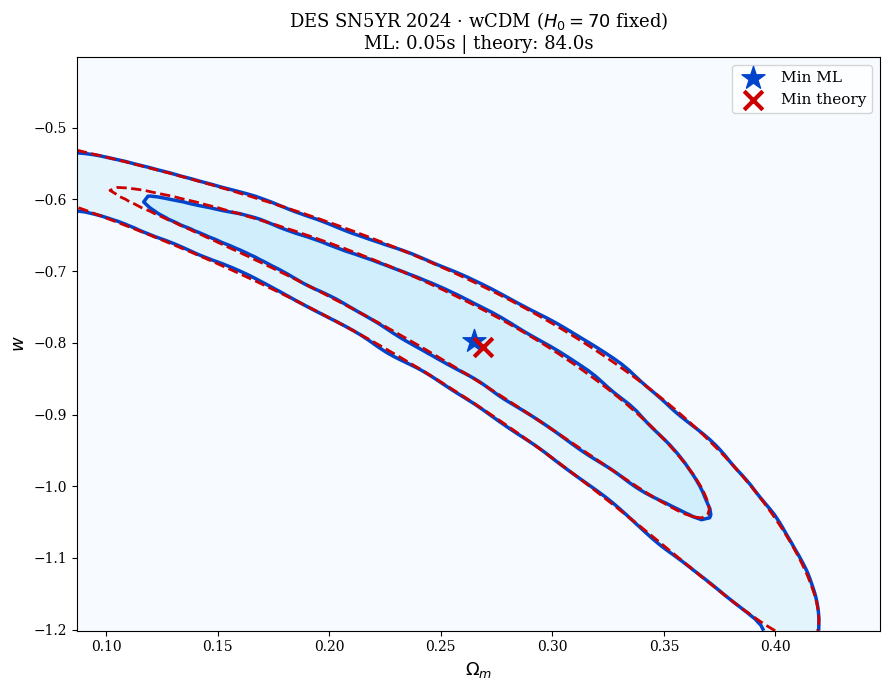

{'Z_ml': array([[2421.5474, 2411.3308, 2393.7507, ..., 1657.3551, 1657.8827,
         1658.1885],
        [2415.4006, 2405.2258, 2387.7065, ..., 1657.4391, 1657.976 ,
         1658.2869],
        [2403.967 , 2393.8728, 2376.4756, ..., 1657.5988, 1658.1531,
         1658.4736],
        ...,
        [1705.9371, 1706.5549, 1707.6359, ..., 1911.5531, 1913.0647,
         1913.9579],
        [1709.5543, 1710.1919, 1711.2972, ..., 1915.8374, 1917.3329,
         1918.2201],
        [1711.601 , 1712.2441, 1713.3538, ..., 1918.2758, 1919.7617,
         1920.6449]], shape=(100, 100), dtype=float32),
 'Z_th': array([[          nan,           nan,           nan, ..., 1657.08629027,
         1657.98568802, 1658.97947484],
        [          nan,           nan,           nan, ..., 1657.31675562,
         1658.26119402, 1659.29875621],
        [          nan,           nan,           nan, ..., 1657.57846446,
         1658.56764842, 1659.64869555],
        ...,
        [          nan,           nan,   

In [92]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(REF['Om']-0.18, REF['Om']+0.18),
    y_range=(REF['w']-0.40, REF['w']+0.40),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DES SN5YR 2024 · wCDM ($H_0=70$ fixed)",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=None,
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_beeswarm.png


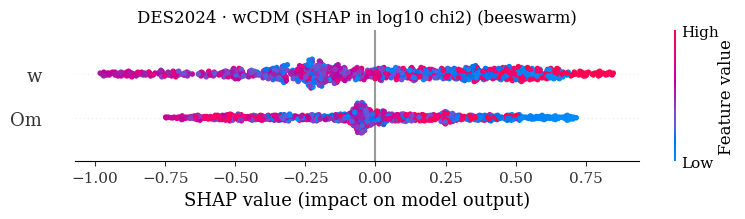

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_bar.png


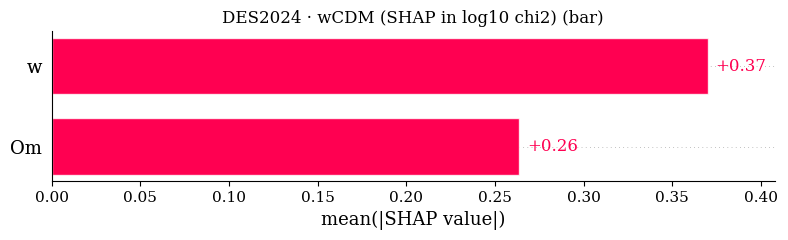

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_waterfall.png


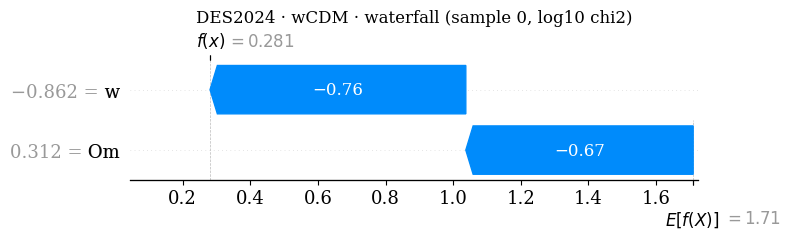

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

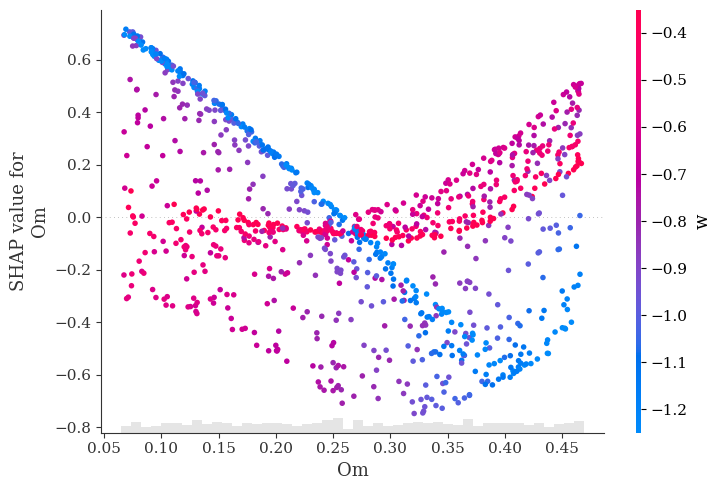

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_w.png


<Figure size 640x480 with 0 Axes>

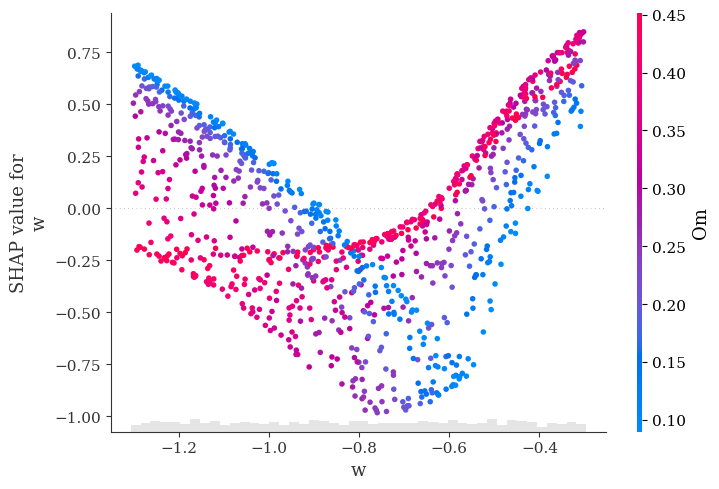

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_w.png')]

In [93]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DES2024 · wCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DES2024 · wCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

## <a id="2-2"></a>2.2 wCDM with DES2025 — 2D (Om, w)

**Data:** DES SN5YR release 2025 (1820 SNe, SNANA format).
**Model:** `FlatwCDM` with H0 = 70 fixed.
**Cepheids:** **NO**.

The 2025 `STAT+SYS_2025.npz` matrix already provides the inverse of the full
STAT+SYS covariance as a packed upper triangle — the loader unpacks it and
uses it directly.


In [94]:
SECTION = "2_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
H0_FIXED = 70.0

des = load_des_2025()
print(f"DES SN5YR 2025: {len(des)} SNe, z [{des.z.min():.3f}, {des.z.max():.3f}]")

def chi2_fn(Om, w):
    return chi2_sne_des(des, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3, -1.0])))
_m.limits = [(0.05, 0.55), (-1.6, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2025: 1820 SNe, z [0.025, 1.144]
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2611  w=-0.8327
chi2(best-fit) = 1639.03


In [95]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[dict(Om=(max(0.05, REF['Om']-0.20), REF['Om']+0.20),
                     w=(REF['w']-0.50, REF['w']+0.50), _n=8_000)],
        anchor=REF, n_anchor=2000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_2_dataset.csv)
Evaluating chi2 at 8000 points across 11 cores...


     2000/8000 ( 25.0%) | elapsed   80.4s | ETA  241.1s |     25 pts/s
     4000/8000 ( 50.0%) | elapsed  157.3s | ETA  157.3s |     25 pts/s
     6000/8000 ( 75.0%) | elapsed  233.3s | ETA   77.8s |     26 pts/s
     8000/8000 (100.0%) | elapsed  283.0s | ETA    0.0s |     28 pts/s
  done in 283.1s
  anchor {'Om': 0.2610591129421274, 'w': -0.8327127998802393} -> chi2=1639.030 repeated 2000x
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_2_dataset.csv (10000 rows)
min chi2 = 1639.030


In [96]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=False,
)

  target in shifted-log10: range [0.000, 3.182]
  training: 7.95s | R2=0.99885 | best_iter=548/3000  (early stop, ~82% saved)
  model cached: 2_2_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_learning_curve.png


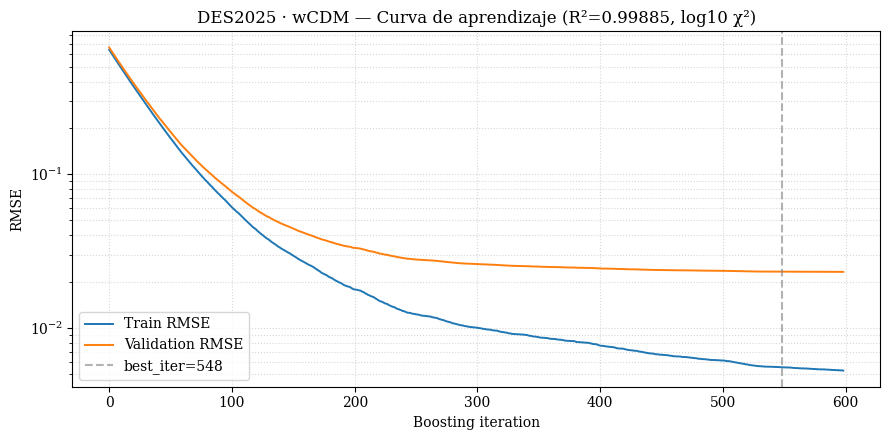

In [97]:
plot_learning_curve(
    info,
    title=f"DES2025 · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=None,
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_Om_w.png


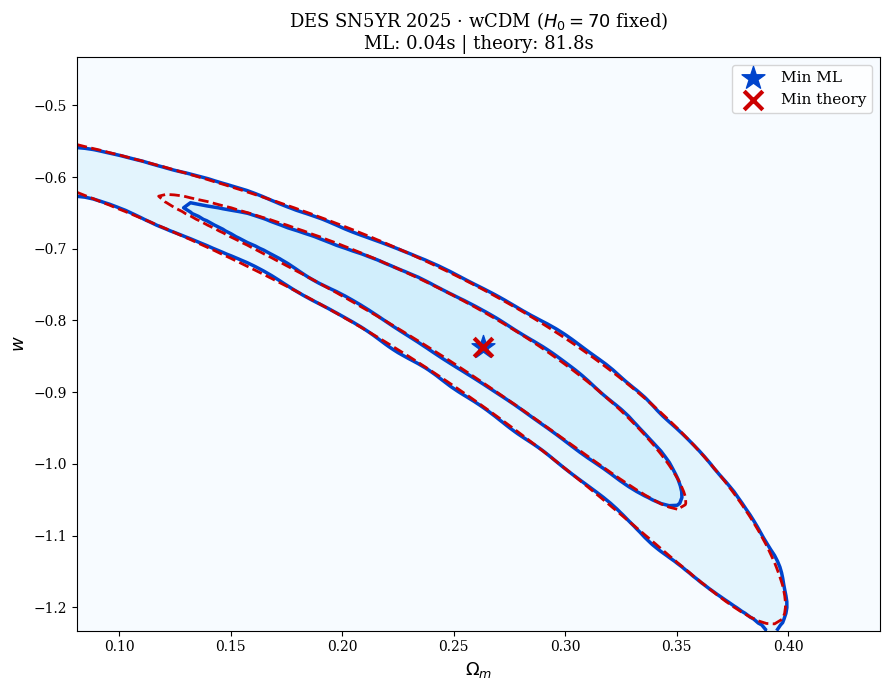

{'Z_ml': array([[2577.2625, 2564.6423, 2542.7097, ..., 1653.0618, 1653.8043,
         1654.2196],
        [2569.654 , 2557.0042, 2535.0454, ..., 1653.2487, 1654.0089,
         1654.434 ],
        [2555.4355, 2542.8013, 2520.9062, ..., 1653.592 , 1654.3857,
         1654.8296],
        ...,
        [1696.2461, 1696.8821, 1698.0127, ..., 1948.9152, 1950.7799,
         1951.8652],
        [1700.1012, 1700.7494, 1701.892 , ..., 1953.6912, 1955.5178,
         1956.58  ],
        [1702.2638, 1702.9137, 1704.0541, ..., 1956.395 , 1958.1996,
         1959.248 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.037552595138549805,
 'time_th': 81.76209688186646}

In [98]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(REF['Om']-0.18, REF['Om']+0.18),
    y_range=(REF['w']-0.40, REF['w']+0.40),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DES SN5YR 2025 · wCDM ($H_0=70$ fixed)",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=None,
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_beeswarm.png


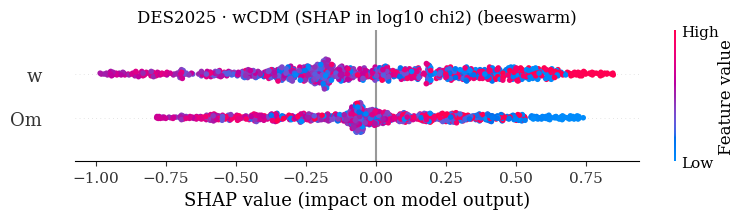

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_bar.png


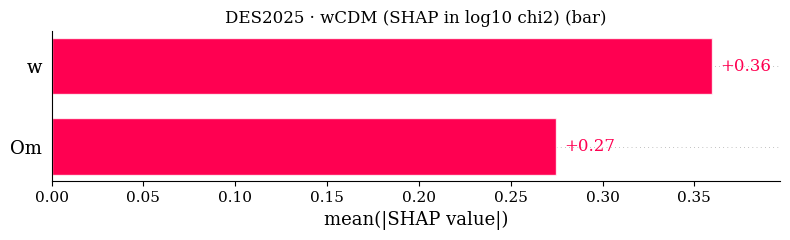

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_waterfall.png


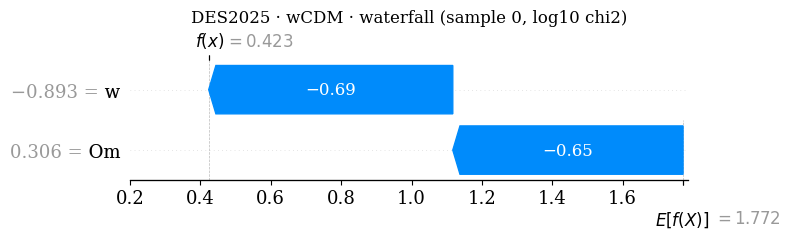

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

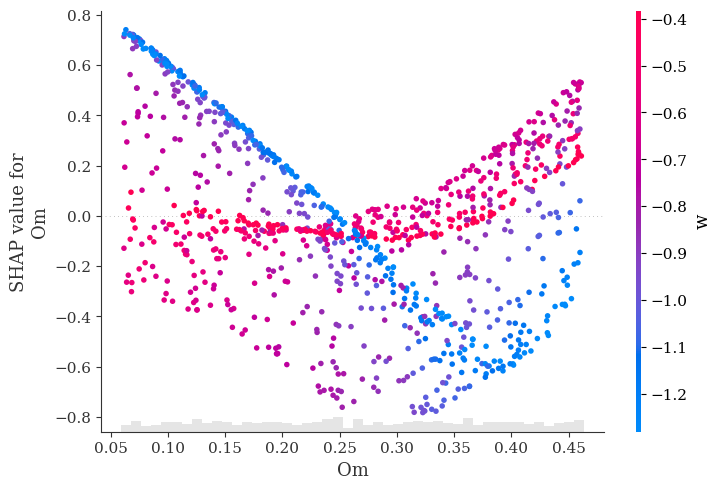

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_w.png


<Figure size 640x480 with 0 Axes>

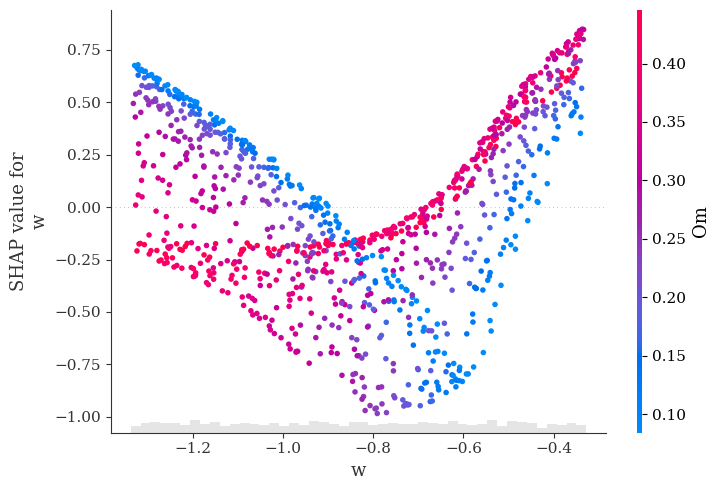

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_w.png')]

In [99]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DES2025 · wCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DES2025 · wCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

## <a id="2-3"></a>2.3 w0waCDM with DES2024 — 3D (Om, w0, wa)

**Data:** DES-SN5YR 2024.
**Model:** `Flatw0waCDM` (CPL) with H0 = 70 fixed.
**Cepheids:** **NO**.


In [100]:
SECTION = "2_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
H0_FIXED = 70.0

des = load_des_2024()
print(f"DES SN5YR 2024: {len(des)} SNe")

def chi2_fn(Om, w0, wa):
    return chi2_sne_des(des, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)

# SN-only w0waCDM: wa is weakly constrained by SNe alone; REF.wa=0 (LCDM anchor)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, w0: chi2_fn(Om=Om, w0=w0, wa=0.0), Om=0.3, w0=-1.0)
_m.limits = [(0.05, 0.6), (-2.5, 0.2)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2024: 1829 SNe
Locating best-fit (wa=0 fixed, SN-only)...
Auto-detected best-fit:  Om=0.2670  w0=-0.8019  wa=0.0000
chi2(best-fit) = 1647.67


In [101]:
def builder():
    N = 5_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.0, 0.0), wa=(-4.0, 2.0), Om=REF['Om'], _n=N),
            dict(Om=(0.1, 0.5), w0=(-2.0, 0.0), wa=REF['wa'],  _n=N),
            dict(Om=(0.1, 0.5), wa=(-4.0, 2.0), w0=REF['w0'],  _n=N),
        ],
        random_box=dict(Om=(0.05, 0.65), w0=(-3.0, 0.5), wa=(-5.0, 4.0)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_3_dataset.csv
min chi2 = 1642.532


  loading cached model: 2_3_model.ubj
  R2=0.99725 | best_iter=1012 | n_train=25,500 | n_val=4,500
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_learning_curve.png


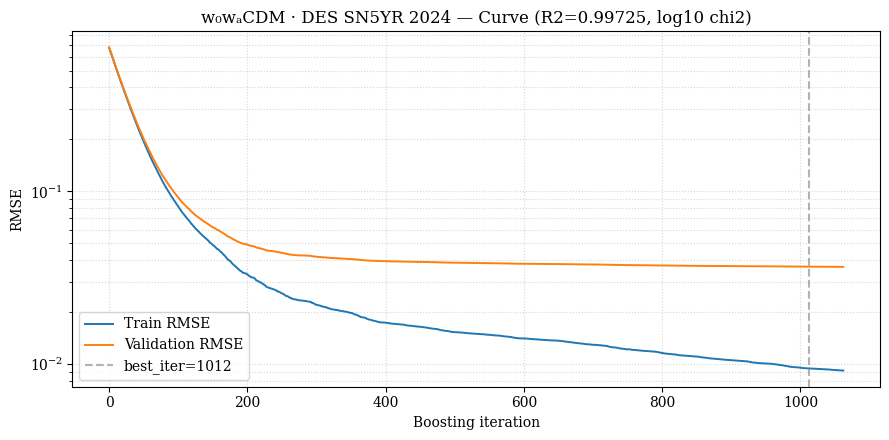

In [102]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=False,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM · DES SN5YR 2024 — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_Om_w0.png


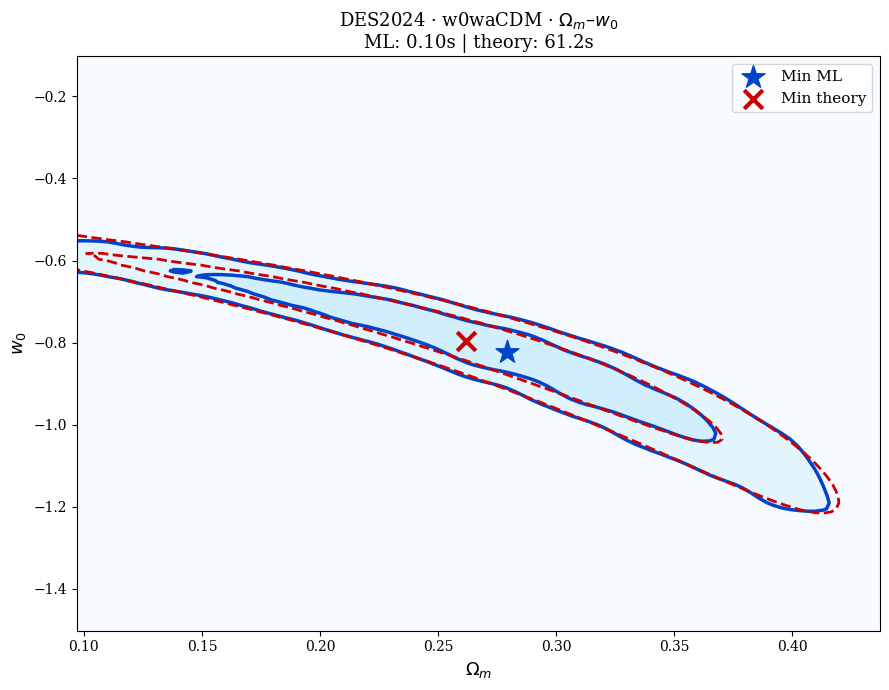

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8019061950675828}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_Om_wa.png


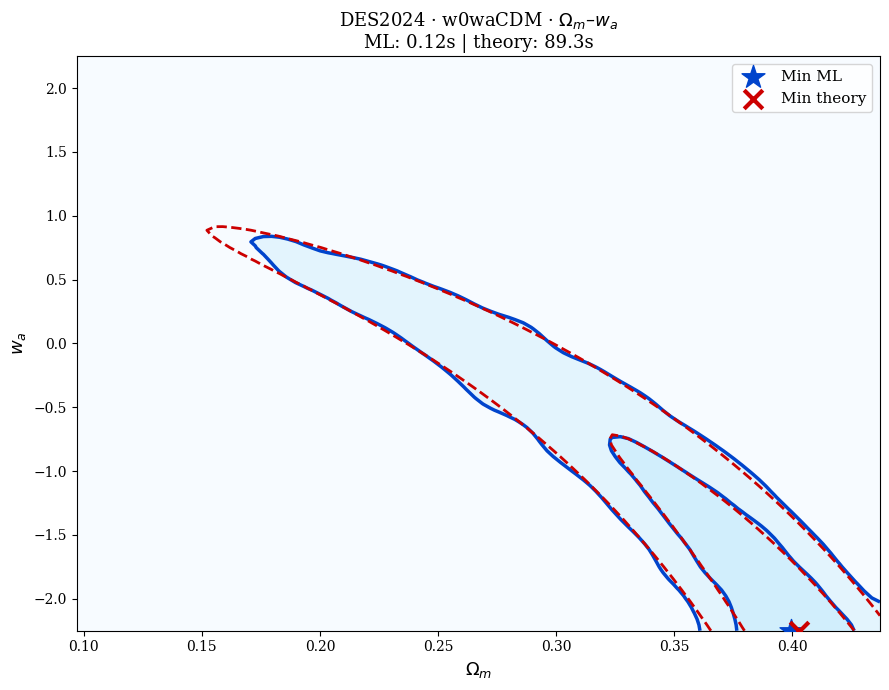

--- $w_a$ vs $w_0$  ({'Om': 0.26704995736857207}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_w0_wa.png


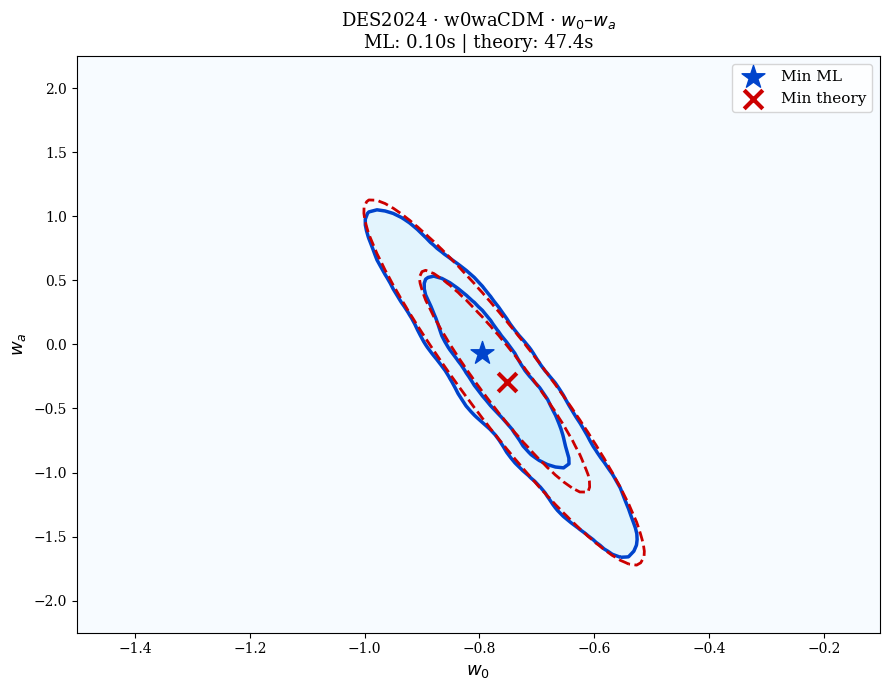

In [103]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.17, REF['Om']+0.17),
    w0=(REF['w0']-0.70, REF['w0']+0.70),
    wa=(REF['wa']-2.25, REF['wa']+2.25),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','w0'), ('Om','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DES2024 · w0waCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_beeswarm.png


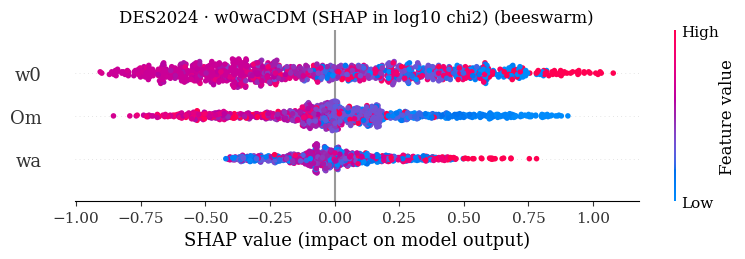

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_bar.png


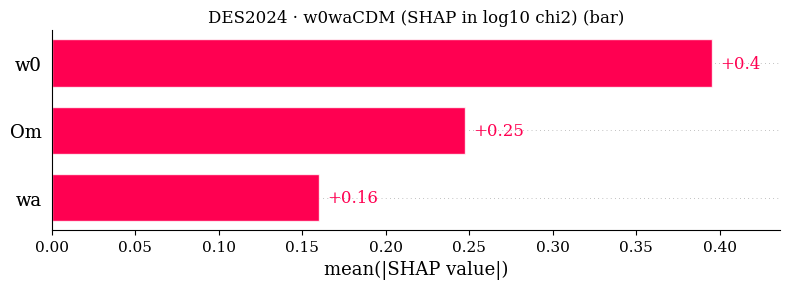

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_waterfall.png


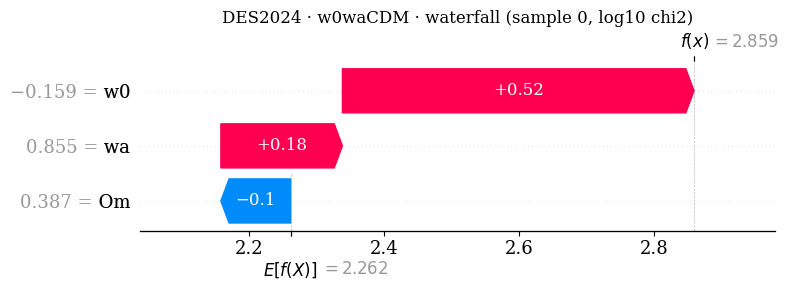

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

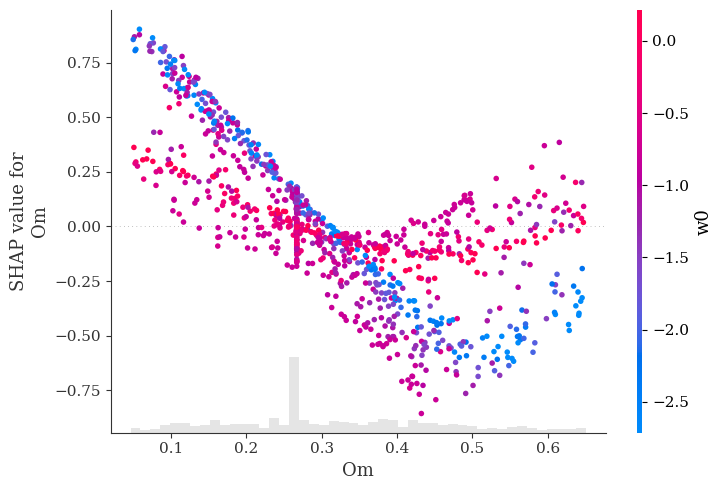

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_w0.png


<Figure size 640x480 with 0 Axes>

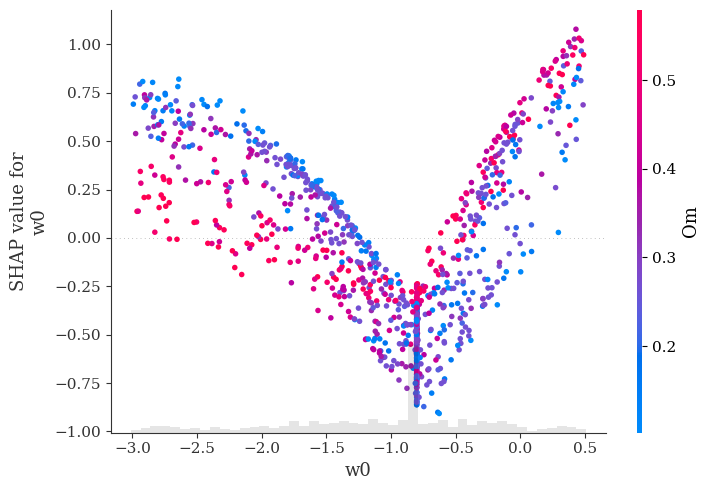

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_wa.png


<Figure size 640x480 with 0 Axes>

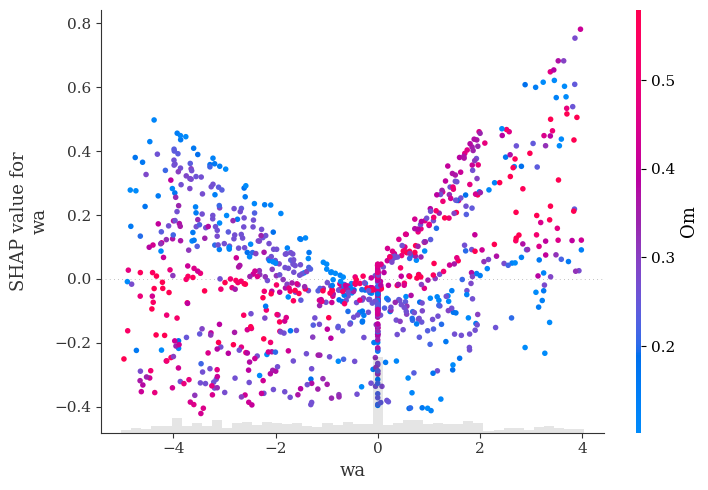

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_wa.png')]

In [104]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DES2024 · w0waCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DES2024 · w0waCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  87 it/s  |  ETA 55s  |  acc 0.34  |  diagonal
  step   400/5000  |  95 it/s  |  ETA 49s  |  acc 0.33  |  multivar
  step   600/5000  |  98 it/s  |  ETA ≤2s  |  acc 0.28  |  τ=36.9  ESS=2778/5000  |  multivar
  step   800/5000  |  68 it/s  |  ETA ≤1s  |  acc 0.25  |  τ=46.3  ESS=4427/5000  |  multivar
  step  1000/5000  |  74 it/s  |  ETA ≤0s  |  acc 0.24  |  τ=54.6  ESS=5626/5000  |  multivar
  done: 13.7s  |  73 it/s  |  acceptance 0.239  |  multivariate proposal
  flat chain: 307,712 samples (512 chains × 601 steps)  |  τ_max=54.6  |  ESS=5635
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_corner.png


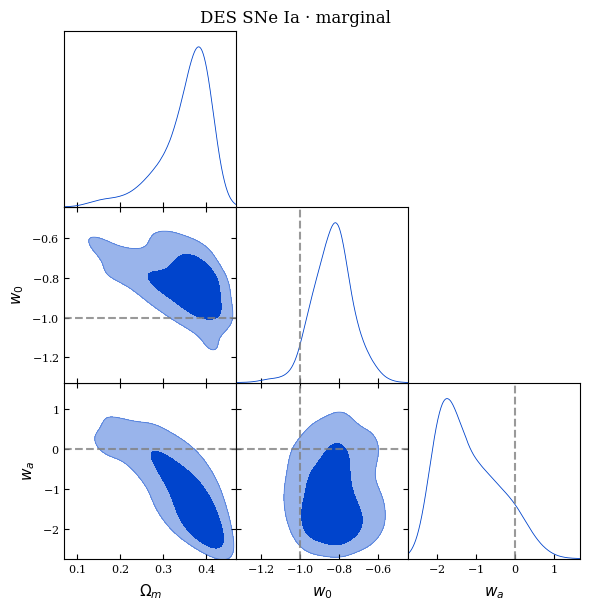

array([[ 0.30638736, -0.85484242, -0.56617928],
       [ 0.39199901, -0.79818243, -1.92808235],
       [ 0.10090217, -0.59096187, -0.08047534],
       ...,
       [ 0.32145795, -0.80650675, -0.48741436],
       [ 0.38916296, -0.99308056, -1.3541292 ],
       [ 0.35161969, -1.05217004,  0.30563271]], shape=(307712, 3))

In [105]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DES SNe Ia · marginal",
    save_path=None,
    show=True,
)

## <a id="2-4"></a>2.4 w0waCDM with DES2025 — 3D (Om, w0, wa)

**Data:** DES SN5YR 2025 (final release).
**Model:** `Flatw0waCDM` (CPL) with H0 = 70 fixed.
**Cepheids:** **NO**.


In [106]:
SECTION = "2_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
H0_FIXED = 70.0

des = load_des_2025()
print(f"DES SN5YR 2025: {len(des)} SNe")

def chi2_fn(Om, w0, wa):
    return chi2_sne_des(des, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)

# SN-only w0waCDM: wa is weakly constrained by SNe alone; REF.wa=0 (LCDM anchor)
import types
from iminuit import Minuit
print("Locating best-fit (wa=0 fixed, SN-only)...")
_m = Minuit(lambda Om, w0: chi2_fn(Om=Om, w0=w0, wa=0.0), Om=0.3, w0=-1.0)
_m.limits = [(0.05, 0.6), (-2.5, 0.2)]
_m.migrad()
res_opt = types.SimpleNamespace(
    fun=chi2_fn(Om=float(_m.values['Om']), w0=float(_m.values['w0']), wa=0.0),
    x=[float(_m.values['Om']), float(_m.values['w0']), 0.0]
)
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


DES SN5YR 2025: 1820 SNe
Locating best-fit (wa=0 fixed, SN-only)...
Auto-detected best-fit:  Om=0.2611  w0=-0.8327  wa=0.0000
chi2(best-fit) = 1639.03


In [107]:
def builder():
    N = 5_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.5, 0.2), wa=(-3.5, 2.0), Om=REF['Om'], _n=N),
            dict(Om=(0.1, 0.6), w0=(-2.5, 0.2), wa=REF['wa'],  _n=N),
            dict(Om=(0.1, 0.6), wa=(-3.5, 2.0), w0=REF['w0'],  _n=N),
        ],
        random_box=dict(Om=(0.05, 0.65), w0=(-3.0, 0.5), wa=(-4.0, 3.0)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_4_dataset.csv
min chi2 = 1635.175


  loading cached model: 2_4_model.ubj


  R2=0.99739 | best_iter=918 | n_train=25,500 | n_val=4,500
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_learning_curve.png


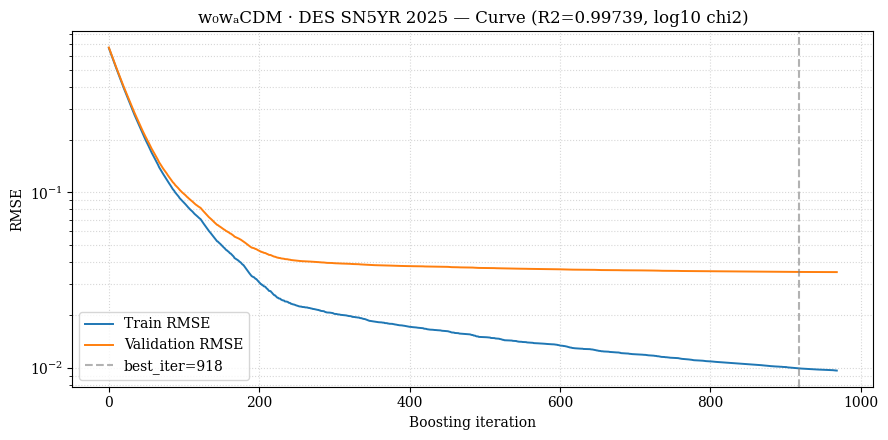

In [108]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=None,
    force_retrain=False,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM · DES SN5YR 2025 — Curve (R2={info['r2']:.5f}, log10 chi2)",
    save_path=None,
    show=True,
)


--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_Om_w0.png


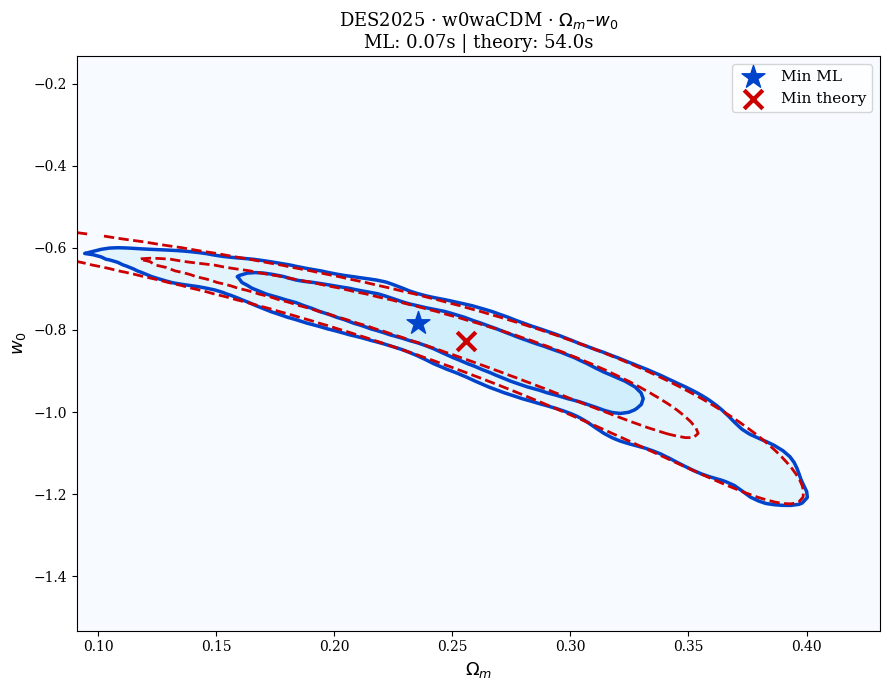

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8327492323119542}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_Om_wa.png


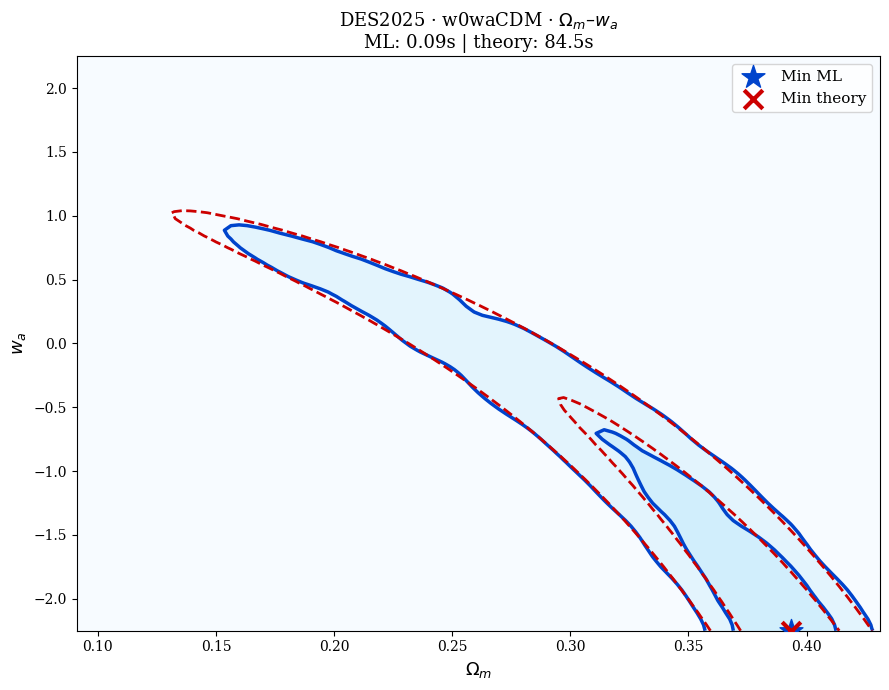

--- $w_a$ vs $w_0$  ({'Om': 0.26107362936495015}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_w0_wa.png


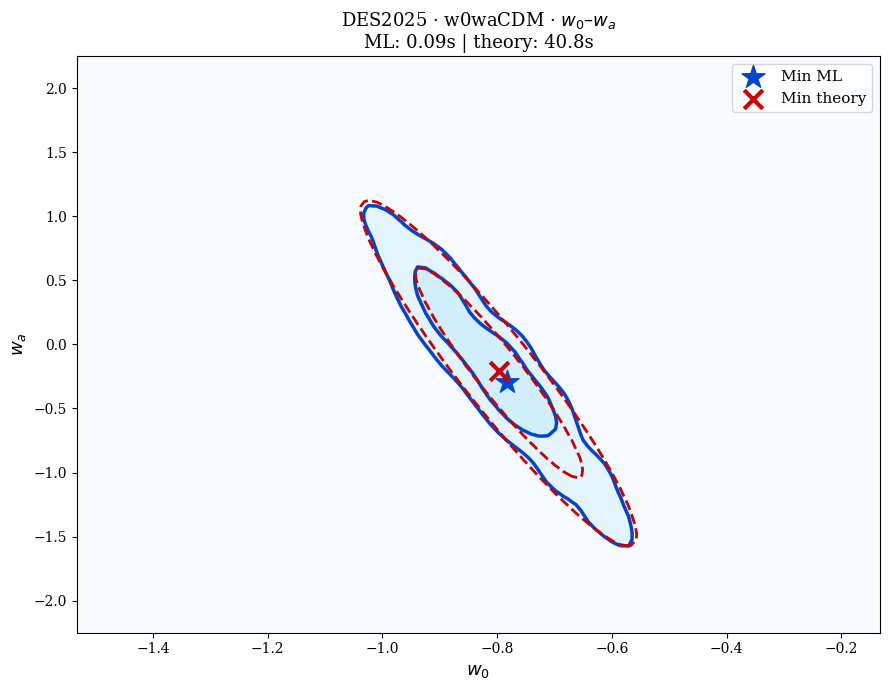

In [109]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(
    Om=(REF['Om']-0.17, REF['Om']+0.17),
    w0=(REF['w0']-0.70, REF['w0']+0.70),
    wa=(REF['wa']-2.25, REF['wa']+2.25),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','w0'), ('Om','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DES2025 · w0waCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=None,
        show=True, **common,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_beeswarm.png


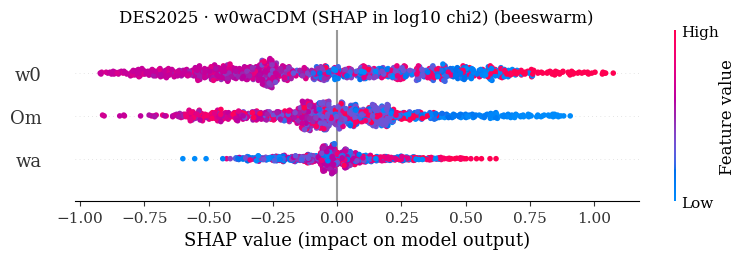

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_bar.png


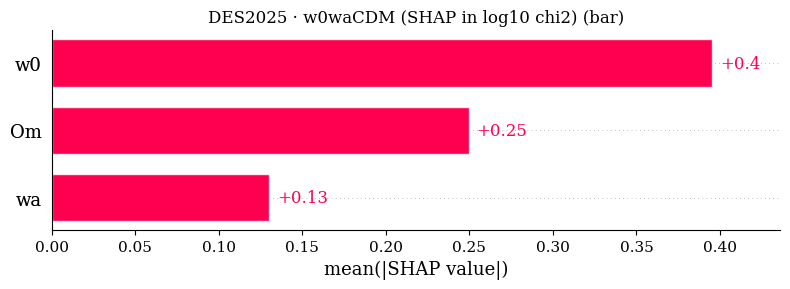

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_waterfall.png


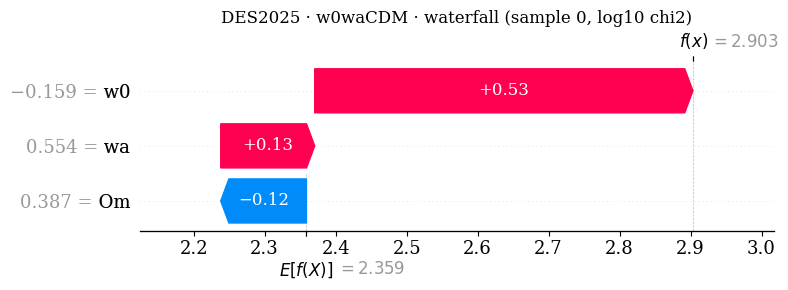

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

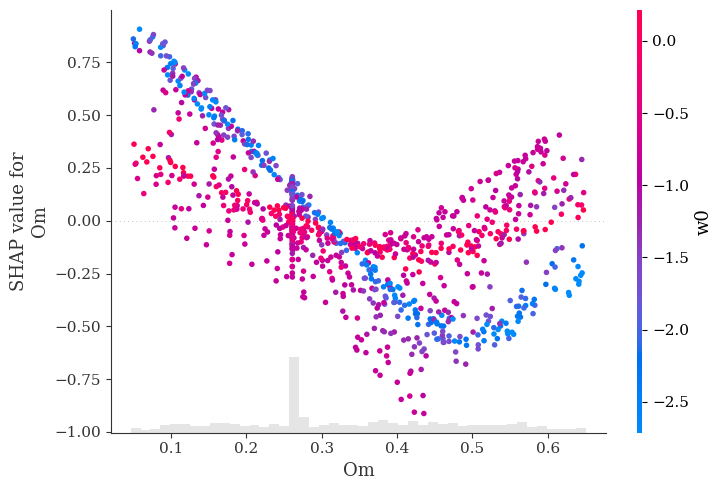

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_w0.png


<Figure size 640x480 with 0 Axes>

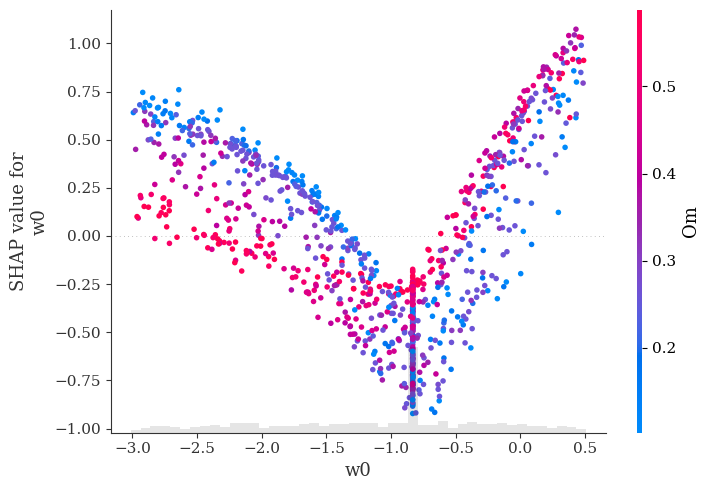

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_wa.png


<Figure size 640x480 with 0 Axes>

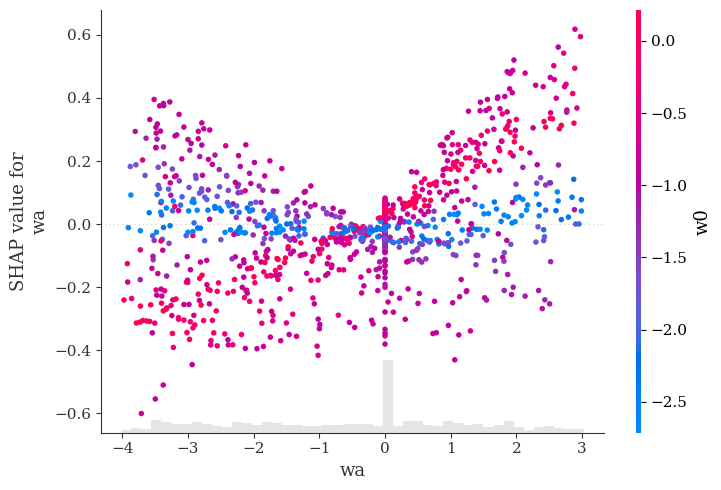

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_wa.png')]

In [110]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=None, prefix=SECTION,
    title="DES2025 · w0waCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=None,
    title="DES2025 · w0waCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=None, prefix=SECTION,
    show=True,
)

--- corner marginal: 512 chains × 5000 steps (burn-in 400, ndim=3) ---
  loading CPU booster copy...
  step   200/5000  |  82 it/s  |  ETA 58s  |  acc 0.39  |  diagonal
  step   400/5000  |  73 it/s  |  ETA 63s  |  acc 0.40  |  multivar
  step   600/5000  |  82 it/s  |  ETA ≤3s  |  acc 0.33  |  τ=44.4  ESS=2307/5000  |  multivar
  step   800/5000  |  87 it/s  |  ETA ≤1s  |  acc 0.29  |  τ=51.9  ESS=3945/5000  |  multivar
  step  1000/5000  |  91 it/s  |  ETA ≤1s  |  acc 0.27  |  τ=72.6  ESS=4229/5000  |  multivar
  step  1200/5000  |  94 it/s  |  ETA ≤0s  |  acc 0.25  |  τ=67.5  ESS=6072/5000  |  multivar
  done: 12.9s  |  93 it/s  |  acceptance 0.254  |  multivariate proposal
  flat chain: 410,112 samples (512 chains × 801 steps)  |  τ_max=67.5  |  ESS=6080
Removed no burn in
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_corner.png


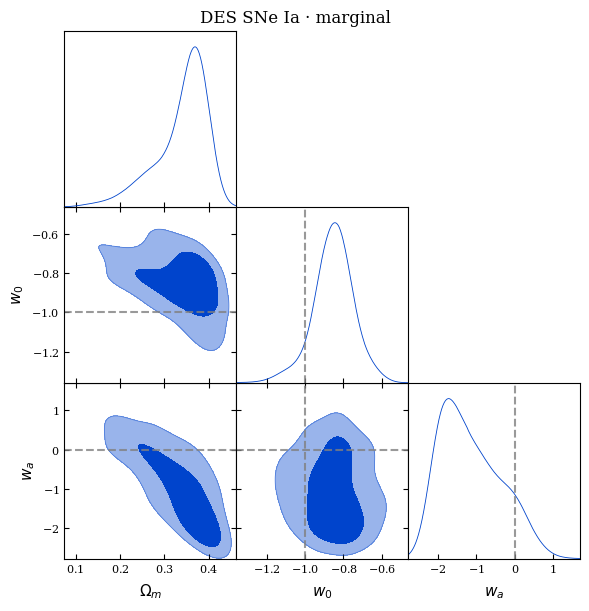

array([[ 0.3115294 , -0.85798389, -0.68128663],
       [ 0.37835413, -0.79863358, -1.59017944],
       [ 0.3607077 , -0.93412864, -0.89323902],
       ...,
       [ 0.37996393, -0.81699282, -1.88950741],
       [ 0.3769193 , -0.83339763, -2.00292039],
       [ 0.40627486, -0.91089225, -2.11293483]], shape=(410112, 3))

In [111]:
# --- Marginalised corner plot (MCMC posterior via XGBoost surrogate) ---
from cosmoml.ml import plot_corner_marginal
plot_corner_marginal(
    model, features=FEATURES, ranges=RANGES,
    labels=LABELS, ref=REF,
    markers={k: v for k, v in {'w0': -1.0, 'wa': 0.0}.items() if k in FEATURES},
    title="DES SNe Ia · marginal",
    save_path=None,
    show=True,
)